In [1]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import math, time
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import chardet
import time
import joblib
from datetime import timedelta

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
file_path = 'OutputData/merged_data.csv'
# 检测文件编码
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read())

# 使用检测到的编码
encoding = result['encoding']
df = pd.read_csv(file_path, encoding=encoding)
df

,日期,经度,纬度,高程,日降雨量,涌水量
0,2023-01-01,400093.254,3044617.466,340,1.747,201.500
1,2023-01-02,400093.254,3044617.466,340,3.160,201.125
2,2023-01-03,400093.254,3044617.466,340,0.857,200.750
3,2023-01-04,400093.254,3044617.466,340,1.712,200.375
4,2023-01-05,400093.254,3044617.466,340,1.942,200.000
...,...,...,...,...,...,...
4149,2024-05-07,401223.552,3044155.756,670,10.717,17.600
4150,2024-05-08,401223.552,3044155.756,670,5.388,17.200
4151,2024-05-09,401223.552,3044155.756,670,3.532,16.800
4152,2024-05-10,401223.552,3044155.756,670,0.221,16.400


# 划分数据集函数

In [3]:
# target为要输入的数据,lookback为序列长度
# def split_data(target, lookback):
#     data_raw = target.to_numpy() 
#     data = []
    
#     # you can free play（seq_length）
#     for index in range(len(data_raw) - lookback + 1 ): 
#         data.append(data_raw[index: index + lookback])
    
#     data = np.array(data);

#     #手动设置测试集为30天
#     test_set_size = 30
#     train_set_size = data.shape[0] - (test_set_size)
    
#     x_train = data[:train_set_size,:-1,:]
#     y_train = data[:train_set_size,-1,1:]
    
#     x_test = data[train_set_size:,:-1,:]
#     y_test = data[train_set_size:,-1,1:]
    
#     return [x_train, y_train, x_test, y_test]

In [4]:
# target为要输入的数据,lookback为序列长度
def split_data(target, lookback, test_ratio=0.1, val_ratio=0.1):
    data_raw = target.to_numpy() 
    data = []
    x_latest = []
    
    # 构建序列数据
    for index in range(len(data_raw) - lookback + 1): 
        data.append(data_raw[index: index + lookback])

    data = np.array(data)
    
    # 计算数据集大小
    total_size = data.shape[0]
    test_set_size = int(total_size * test_ratio)
    # 剩余数据集大小
    total_size = total_size - test_set_size
    # 从剩余数据集中拿0.1来当验证集
    val_set_size = int(total_size * val_ratio)
    # 剩下全部当训练集
    train_set_size = total_size - val_set_size
    
    # 分割数据集
    # 注意:不可以写为y_train = data[:train_set_size, -1, 1:],这样写维度会报错
    x_train = data[:train_set_size, :-1, :]
    y_train = data[:train_set_size, -1, 1:]
    
    x_val = data[train_set_size:train_set_size+val_set_size, :-1, :]
    y_val = data[train_set_size:train_set_size+val_set_size, -1, 1:]
    
    x_test = data[train_set_size+val_set_size:, :-1, :]
    y_test = data[train_set_size+val_set_size:, -1, 1:]

    x_latest.append(data_raw[(len(data_raw) - lookback + 1) :])
    x_latest = np.array(x_latest);
    
    return [x_train, y_train, x_val, y_val, x_test, y_test, x_latest]

# 模型构建

In [5]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [6]:
# 简单的日志记录器，支持日志恢复功能
class Logger:
    def __init__(self, log_file_path):
        self.log_file = log_file_path

        # 创建日志目录（如果不存在）
        os.makedirs(os.path.dirname(log_file_path), exist_ok=True)

        # 清空日志文件内容或创建新文件
        try:
            with open(log_file_path, 'w', encoding='utf-8') as f:
                f.write(f"训练开始: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        except Exception as e:
            print(f"日志写入失败: {e}")

    def log(self, message):
        """记录日志到文件并打印到控制台"""
        print(message)  # 保持原有打印

        # 写入主日志文件
        with open(self.log_file, 'a', encoding='utf-8') as f:
            f.write(f"{message}\n")

Group: (400093.254, 3044617.466, 340)
模型标准化格式保存路径：lstmscaler/(400093.254, 3044617.466, 340)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(400093.254, 3044617.466, 340)best_model.pth
Epoch 0 MSE: 0.2853716313838959
Epoch 0 val RMSE: 9.911961013360125
Best model saved at epoch 0 with Test RMSE: 9.911961013360125
Epoch 1 MSE: 0.2840660512447357
Epoch 1 val RMSE: 6.0263645763697555
Best model saved at epoch 1 with Test RMSE: 6.0263645763697555
Epoch 2 MSE: 0.25632986426353455
Epoch 2 val RMSE: 9.09500711148211
Epoch 3 MSE: 0.2342645674943924
Epoch 3 val RMSE: 9.194203117817208
Epoch 4 MSE: 0.13815392553806305
Epoch 4 val RMSE: 20.09252736122857
Epoch 5 MSE: 0.057055823504924774
Epoch 5 val RMSE: 17.01217574371827
Epoch 6 MSE: 0.038582686334848404
Epoch 6 val RMSE: 15.819747289286102
Epoch 7 MSE: 0.03607389330863952

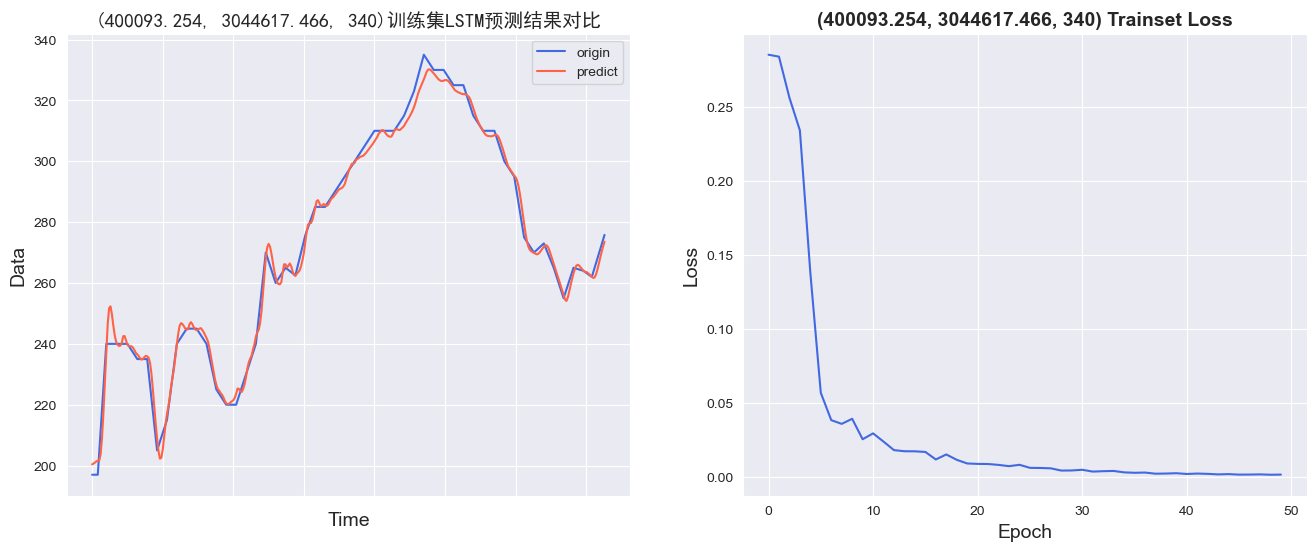

Train Score: 2.93 RMSE
Train Score: 2.25 RMSE
Test Score: 2.25 RMSE
./images/(400093.254, 3044617.466, 340)真实值vs预测值.png保存成功


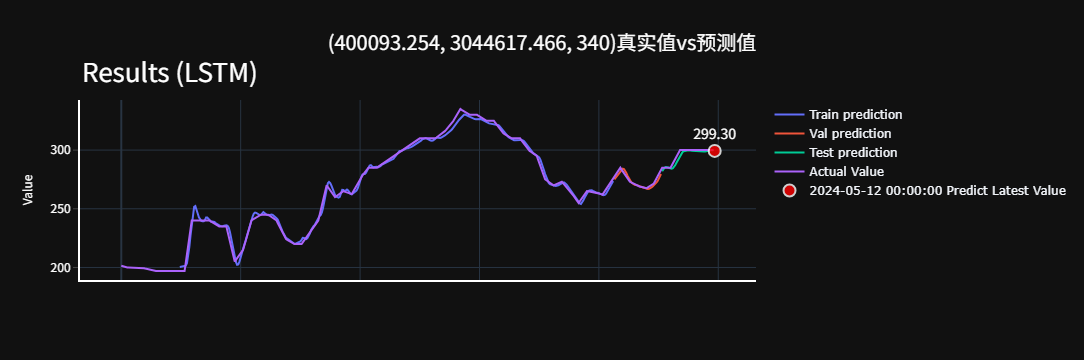

Group: (400119.158, 3044703.654, 670)
模型标准化格式保存路径：lstmscaler/(400119.158, 3044703.654, 670)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(400119.158, 3044703.654, 670)best_model.pth
Epoch 0 MSE: 0.5568363666534424
Epoch 0 val RMSE: 22.9650998906663
Best model saved at epoch 0 with Test RMSE: 22.9650998906663
Epoch 1 MSE: 0.26774996519088745
Epoch 1 val RMSE: 55.396940754177706
Epoch 2 MSE: 0.04783486947417259
Epoch 2 val RMSE: 47.00585381597435
Epoch 3 MSE: 0.03492951765656471
Epoch 3 val RMSE: 46.38139591170958
Epoch 4 MSE: 0.03552801162004471
Epoch 4 val RMSE: 49.82119640602908
Epoch 5 MSE: 0.03327113017439842
Epoch 5 val RMSE: 50.86142228982345
Epoch 6 MSE: 0.03462700918316841
Epoch 6 val RMSE: 47.942681739989006
Epoch 7 MSE: 0.032143186777830124
Epoch 7 val RMSE: 45.730779560584246
Epoch 8 MSE: 0.0332782715

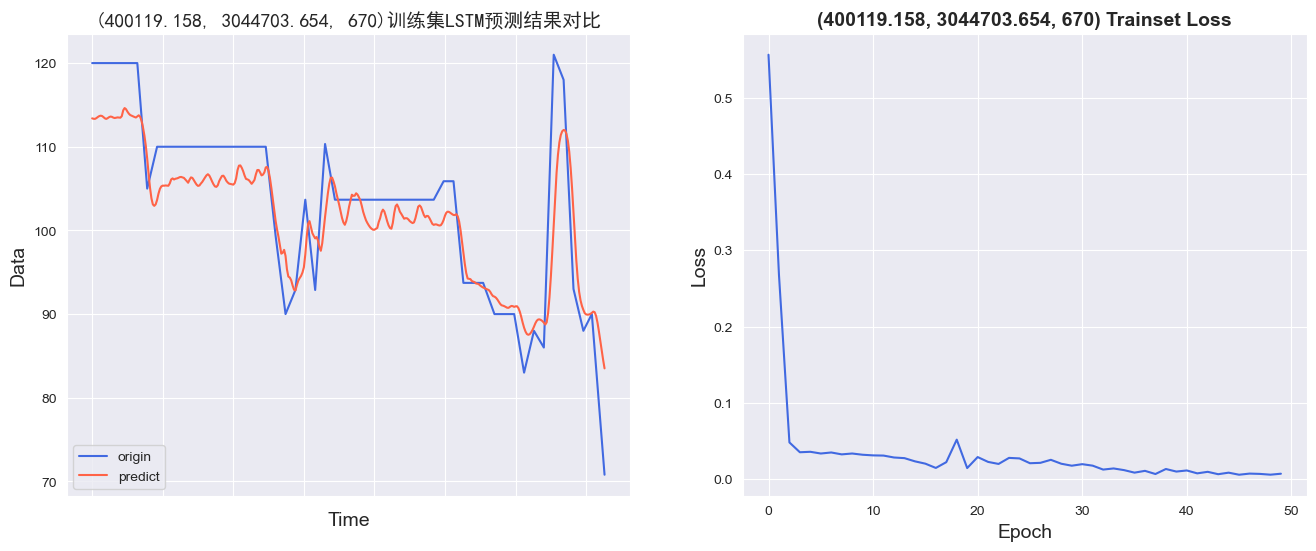

Train Score: 12.59 RMSE
Train Score: 13.56 RMSE
Test Score: 42.17 RMSE
./images/(400119.158, 3044703.654, 670)真实值vs预测值.png保存成功


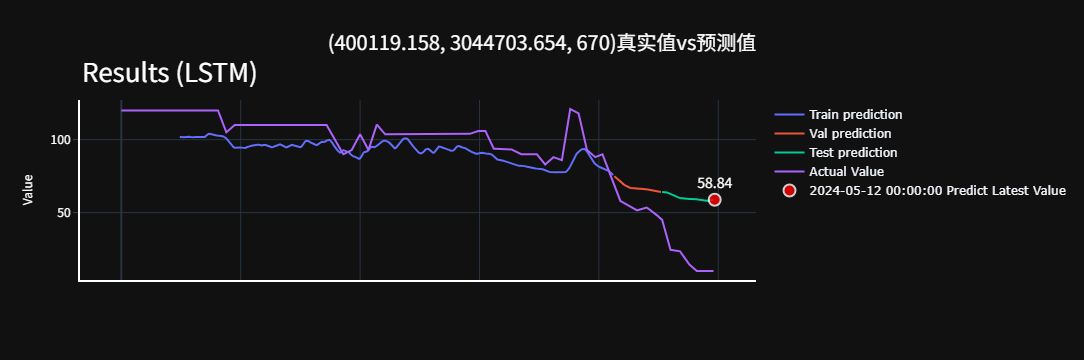

Group: (400277.273, 3044902.064, 430)
模型标准化格式保存路径：lstmscaler/(400277.273, 3044902.064, 430)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(400277.273, 3044902.064, 430)best_model.pth
Epoch 0 MSE: 0.4788079857826233
Epoch 0 val RMSE: 7.604679734849385
Best model saved at epoch 0 with Test RMSE: 7.604679734849385
Epoch 1 MSE: 0.30549558997154236
Epoch 1 val RMSE: 12.03971838232049
Epoch 2 MSE: 0.6955227851867676
Epoch 2 val RMSE: 8.11514623711163
Epoch 3 MSE: 0.2713029384613037
Epoch 3 val RMSE: 7.352140268127153
Best model saved at epoch 3 with Test RMSE: 7.352140268127153
Epoch 4 MSE: 0.3245106041431427
Epoch 4 val RMSE: 7.105439759080494
Best model saved at epoch 4 with Test RMSE: 7.105439759080494
Epoch 5 MSE: 0.34947559237480164
Epoch 5 val RMSE: 7.007491598787691
Best model saved at epoch 5 with Test RMSE: 7

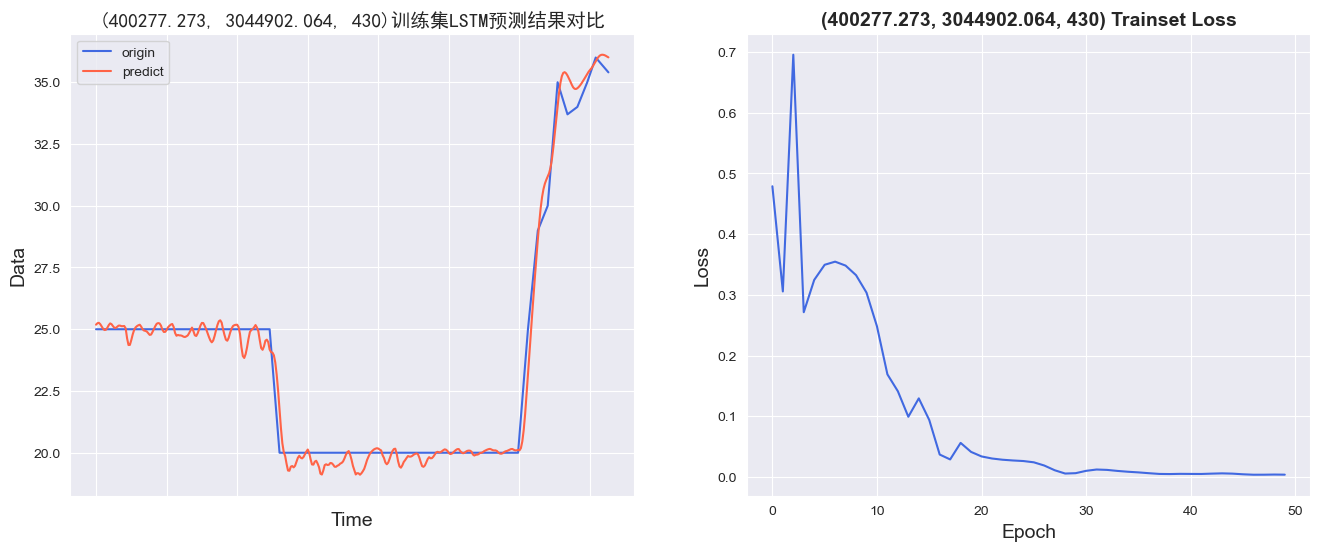

Train Score: 0.64 RMSE
Train Score: 2.66 RMSE
Test Score: 1.10 RMSE
./images/(400277.273, 3044902.064, 430)真实值vs预测值.png保存成功


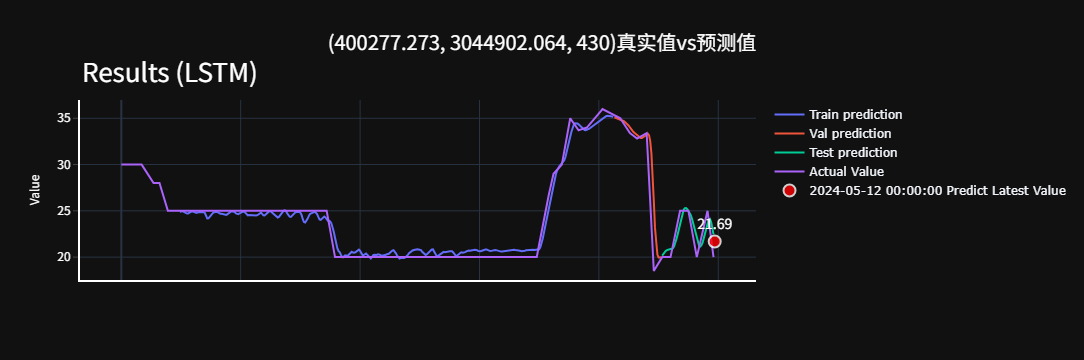

Group: (400530.275, 3043926.857, 670)
模型标准化格式保存路径：lstmscaler/(400530.275, 3043926.857, 670)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(400530.275, 3043926.857, 670)best_model.pth
Epoch 0 MSE: 0.20283621549606323
Epoch 0 val RMSE: 4.718726960182784
Best model saved at epoch 0 with Test RMSE: 4.718726960182784
Epoch 1 MSE: 0.14775808155536652
Epoch 1 val RMSE: 6.155857751423575
Epoch 2 MSE: 0.13684949278831482
Epoch 2 val RMSE: 5.523551799449442
Epoch 3 MSE: 0.11089329421520233
Epoch 3 val RMSE: 8.821565334656501
Epoch 4 MSE: 0.14523190259933472
Epoch 4 val RMSE: 13.17411233130238
Epoch 5 MSE: 0.11045899242162704
Epoch 5 val RMSE: 16.67128008252047
Epoch 6 MSE: 0.15181180834770203
Epoch 6 val RMSE: 15.998162640932932
Epoch 7 MSE: 0.1420803666114807
Epoch 7 val RMSE: 13.821405500165314
Epoch 8 MSE: 0.1177032515

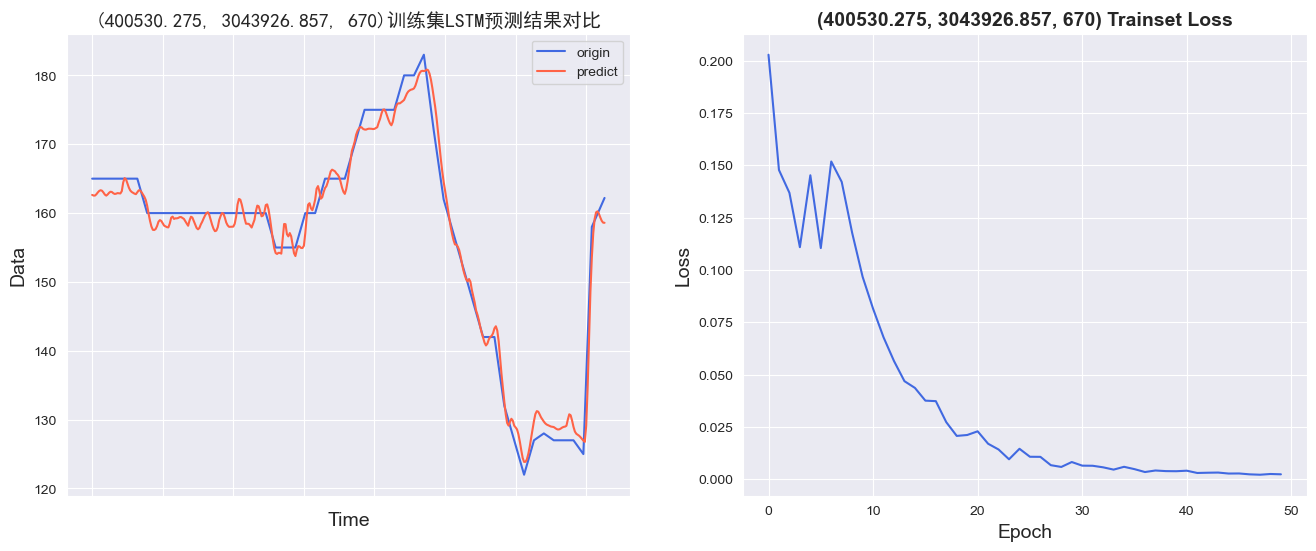

Train Score: 4.16 RMSE
Train Score: 2.09 RMSE
Test Score: 6.66 RMSE
./images/(400530.275, 3043926.857, 670)真实值vs预测值.png保存成功


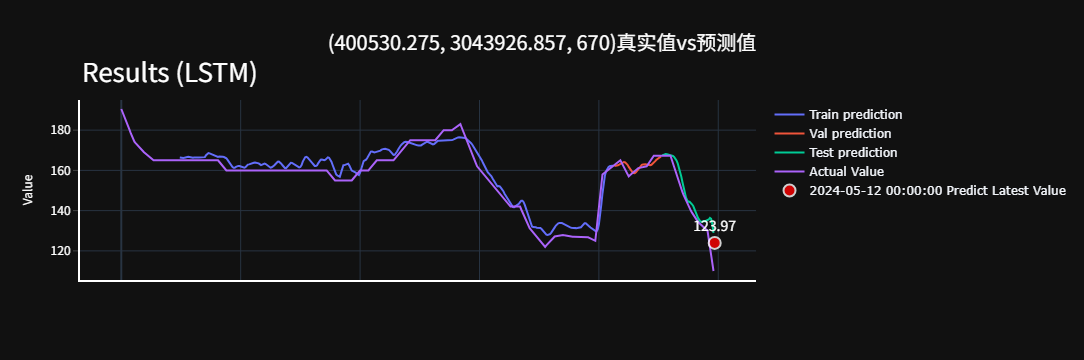

Group: (401142.234, 3043998.544, 490)
模型标准化格式保存路径：lstmscaler/(401142.234, 3043998.544, 490)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(401142.234, 3043998.544, 490)best_model.pth
Epoch 0 MSE: 0.24778439104557037
Epoch 0 val RMSE: 21.66670360072974
Best model saved at epoch 0 with Test RMSE: 21.66670360072974
Epoch 1 MSE: 0.09234268218278885
Epoch 1 val RMSE: 35.53049760087276
Epoch 2 MSE: 0.18714849650859833
Epoch 2 val RMSE: 24.8669015554562
Epoch 3 MSE: 0.047307077795267105
Epoch 3 val RMSE: 22.512428072613787
Epoch 4 MSE: 0.07927154004573822
Epoch 4 val RMSE: 21.984942745423087
Epoch 5 MSE: 0.08809429407119751
Epoch 5 val RMSE: 22.149492231279606
Epoch 6 MSE: 0.08378488570451736
Epoch 6 val RMSE: 22.709609846814438
Epoch 7 MSE: 0.07281450182199478
Epoch 7 val RMSE: 23.596926524576247
Epoch 8 MSE: 0.058582

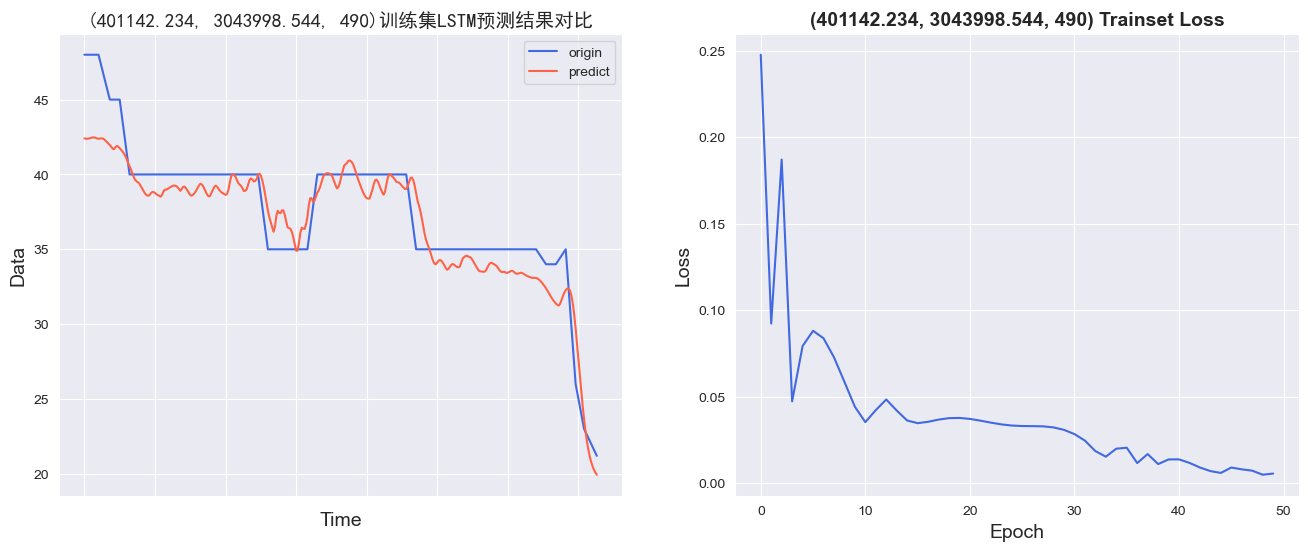

Train Score: 2.33 RMSE
Train Score: 8.73 RMSE
Test Score: 14.14 RMSE
./images/(401142.234, 3043998.544, 490)真实值vs预测值.png保存成功


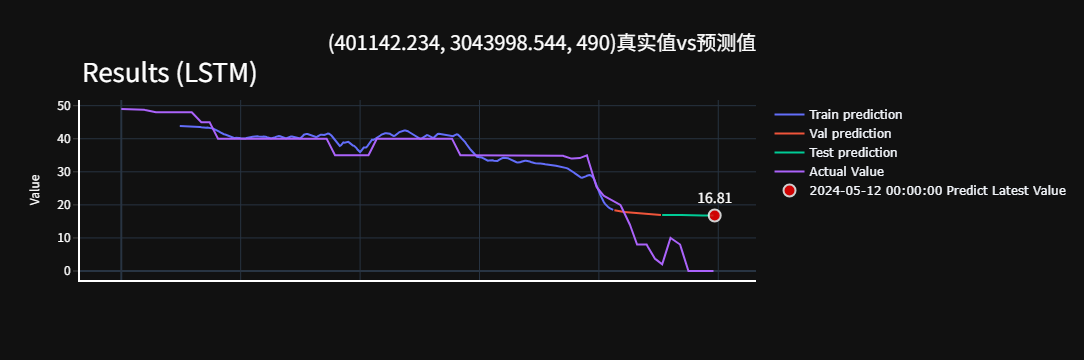

Group: (401142.234, 3043998.544, 760)
模型标准化格式保存路径：lstmscaler/(401142.234, 3043998.544, 760)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(401142.234, 3043998.544, 760)best_model.pth
Epoch 0 MSE: 0.34402814507484436
Epoch 0 val RMSE: 1.5573196748832407
Best model saved at epoch 0 with Test RMSE: 1.5573196748832407
Epoch 1 MSE: 0.10045766085386276
Epoch 1 val RMSE: 7.646452945337706
Epoch 2 MSE: 1.1594444513320923
Epoch 2 val RMSE: 2.5604832784638942
Epoch 3 MSE: 0.07350804656744003
Epoch 3 val RMSE: 1.1937296241499245
Best model saved at epoch 3 with Test RMSE: 1.1937296241499245
Epoch 4 MSE: 0.12660004198551178
Epoch 4 val RMSE: 0.8017483709525154
Best model saved at epoch 4 with Test RMSE: 0.8017483709525154
Epoch 5 MSE: 0.16895507276058197
Epoch 5 val RMSE: 0.701392476436727
Best model saved at epoch 5 with T

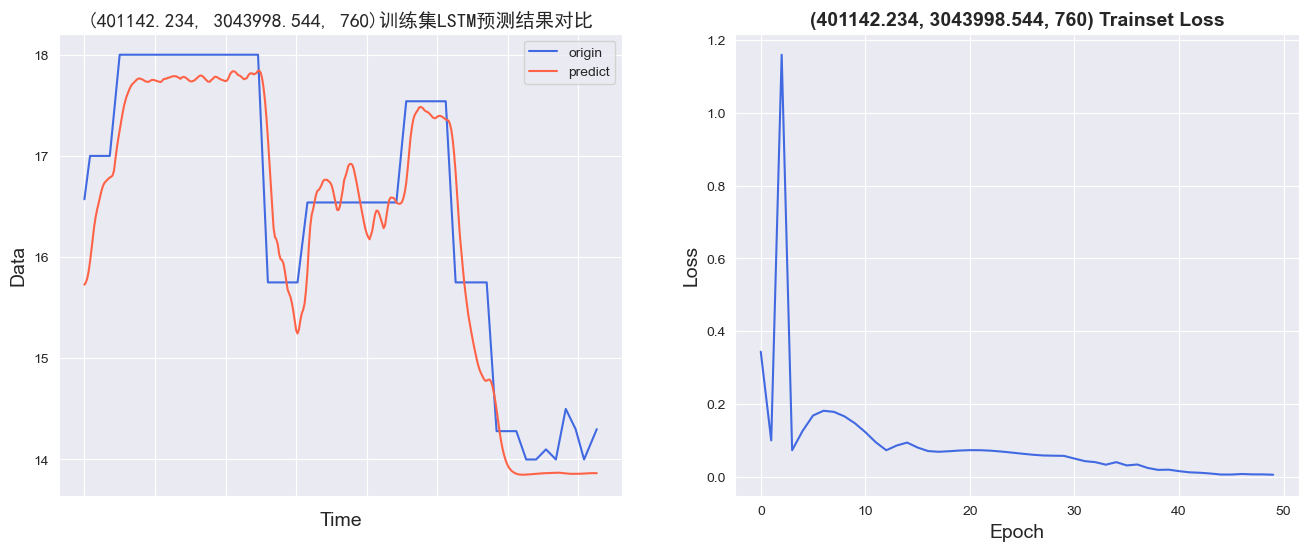

Train Score: 0.43 RMSE
Train Score: 0.17 RMSE
Test Score: 3.74 RMSE
./images/(401142.234, 3043998.544, 760)真实值vs预测值.png保存成功


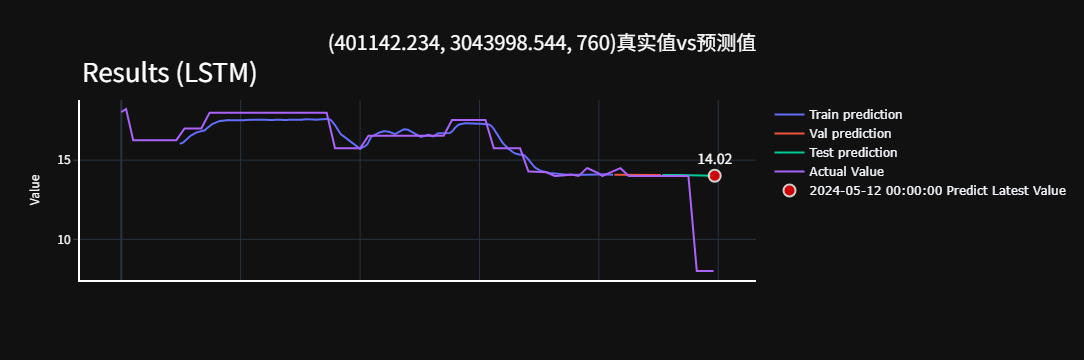

Group: (401223.552, 3044155.756, 490)
模型标准化格式保存路径：lstmscaler/(401223.552, 3044155.756, 490)best_scaler.pkl
x_train.shape =  (106, 49, 2)
y_train.shape =  (106, 1)
x_val.shape =  (11, 49, 2)
y_val.shape =  (11, 1)
x_test.shape =  (12, 49, 2)
y_test.shape =  (12, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(401223.552, 3044155.756, 490)best_model.pth
Epoch 0 MSE: 0.13093751668930054
Epoch 0 val RMSE: 45.85533947320775
Best model saved at epoch 0 with Test RMSE: 45.85533947320775
Epoch 1 MSE: 0.05582576245069504
Epoch 1 val RMSE: 47.046986569944096
Epoch 2 MSE: 0.05669314041733742
Epoch 2 val RMSE: 41.29252069836619
Best model saved at epoch 2 with Test RMSE: 41.29252069836619
Epoch 3 MSE: 0.061114534735679626
Epoch 3 val RMSE: 42.35852774881199
Epoch 4 MSE: 0.05492487549781799
Epoch 4 val RMSE: 44.37449245968553
Epoch 5 MSE: 0.04978034272789955
Epoch 5 val RMSE: 44.555275865175325
Epoch 6 MSE: 0.048831693828105927
Epoch 6 val RMSE: 40.22925028042407
Best model saved at epoch 6 w

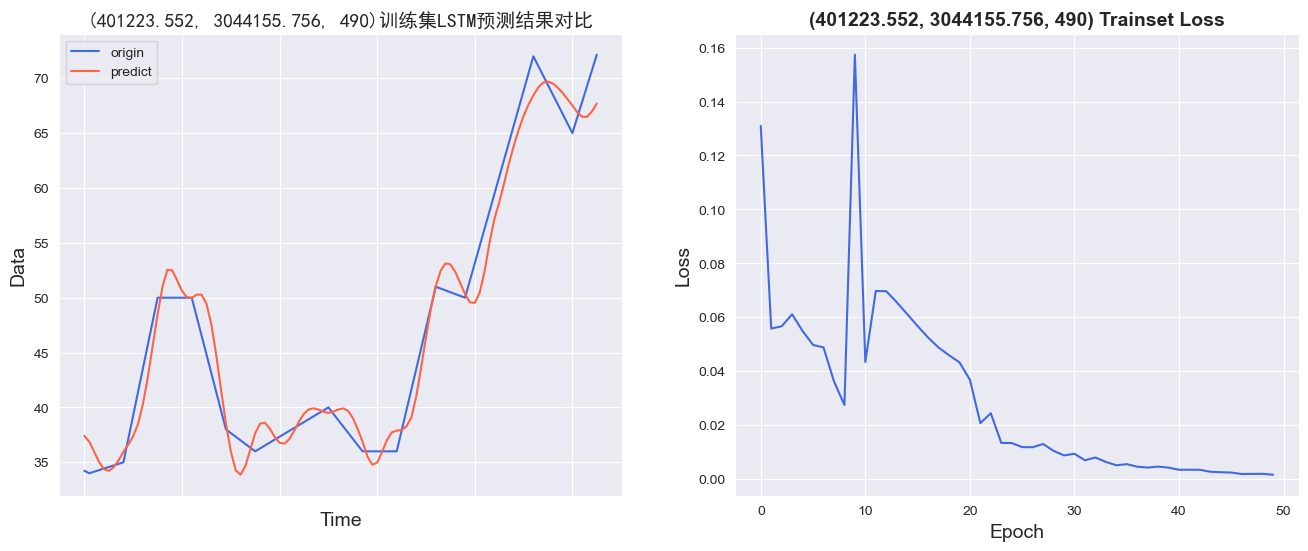

Train Score: 7.82 RMSE
Train Score: 8.48 RMSE
Test Score: 2.20 RMSE
./images/(401223.552, 3044155.756, 490)真实值vs预测值.png保存成功


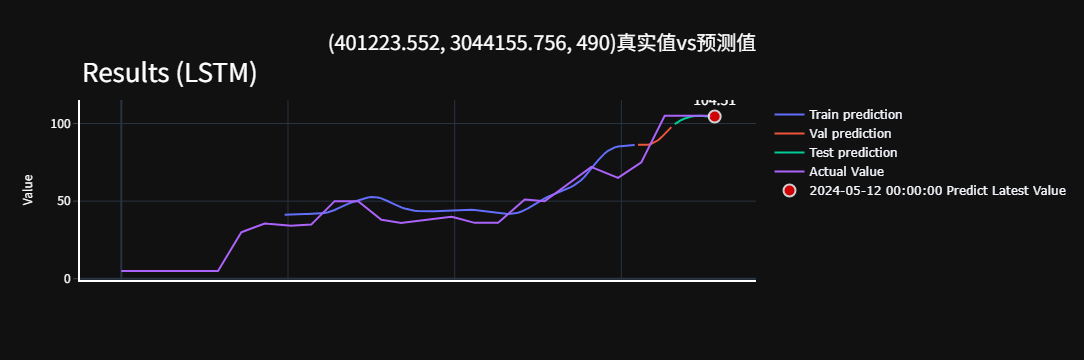

Group: (401223.552, 3044155.756, 610)
模型标准化格式保存路径：lstmscaler/(401223.552, 3044155.756, 610)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(401223.552, 3044155.756, 610)best_model.pth
Epoch 0 MSE: 0.2052583545446396
Epoch 0 val RMSE: 6.953172456386506
Best model saved at epoch 0 with Test RMSE: 6.953172456386506
Epoch 1 MSE: 0.2269211858510971
Epoch 1 val RMSE: 8.379081983879745
Epoch 2 MSE: 0.17129141092300415
Epoch 2 val RMSE: 12.31808917993866
Epoch 3 MSE: 0.15649239718914032
Epoch 3 val RMSE: 9.835235497933168
Epoch 4 MSE: 0.06413537263870239
Epoch 4 val RMSE: 4.866055229829996
Best model saved at epoch 4 with Test RMSE: 4.866055229829996
Epoch 5 MSE: 0.060326967388391495
Epoch 5 val RMSE: 6.032848087137656
Epoch 6 MSE: 0.14005732536315918
Epoch 6 val RMSE: 5.795798312240676
Epoch 7 MSE: 0.14619529247283936
E

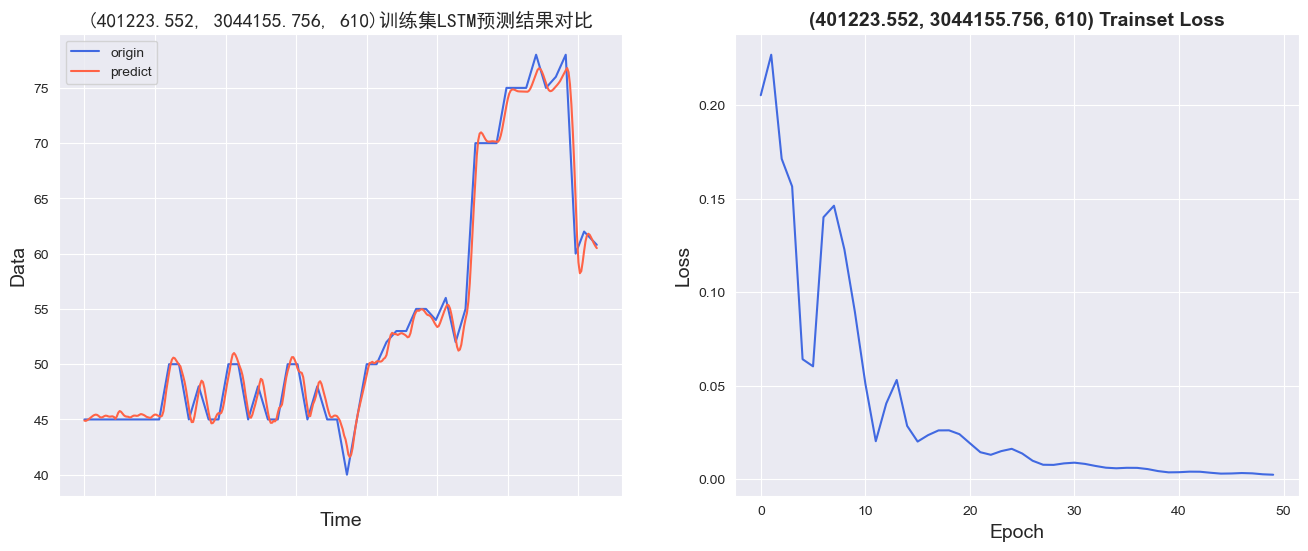

Train Score: 1.20 RMSE
Train Score: 0.76 RMSE
Test Score: 3.17 RMSE
./images/(401223.552, 3044155.756, 610)真实值vs预测值.png保存成功


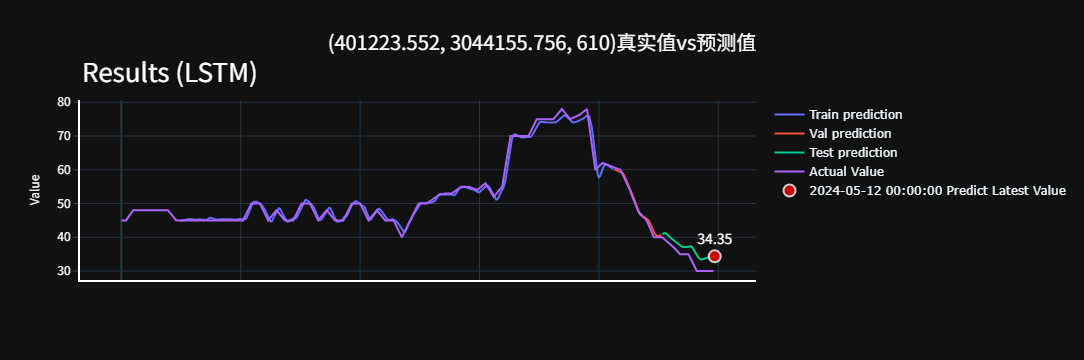

Group: (401223.552, 3044155.756, 670)
模型标准化格式保存路径：lstmscaler/(401223.552, 3044155.756, 670)best_scaler.pkl
x_train.shape =  (364, 49, 2)
y_train.shape =  (364, 1)
x_val.shape =  (40, 49, 2)
y_val.shape =  (40, 1)
x_test.shape =  (44, 49, 2)
y_test.shape =  (44, 1)
x_latest.shape =  (1, 49, 2)
最优模型参数保存路径：lstmmodel/(401223.552, 3044155.756, 670)best_model.pth
Epoch 0 MSE: 0.2414272427558899
Epoch 0 val RMSE: 6.171794340355054
Best model saved at epoch 0 with Test RMSE: 6.171794340355054
Epoch 1 MSE: 0.2625570297241211
Epoch 1 val RMSE: 4.734219488731006
Best model saved at epoch 1 with Test RMSE: 4.734219488731006
Epoch 2 MSE: 0.2220628410577774
Epoch 2 val RMSE: 3.860530047219345
Best model saved at epoch 2 with Test RMSE: 3.860530047219345
Epoch 3 MSE: 0.21515212953090668
Epoch 3 val RMSE: 2.8376283255308437
Best model saved at epoch 3 with Test RMSE: 2.8376283255308437
Epoch 4 MSE: 0.1948755532503128
Epoch 4 val RMSE: 1.4619770125683647
Best model saved at epoch 4 with Test RMSE: 1.46

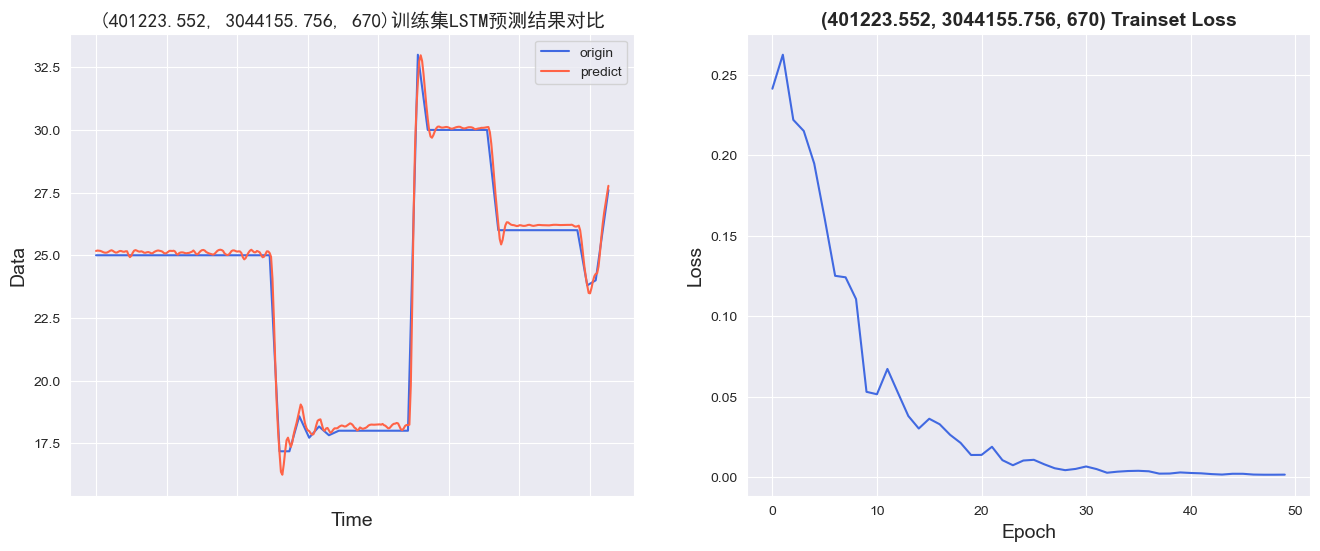

Train Score: 0.32 RMSE
Train Score: 0.64 RMSE
Test Score: 0.31 RMSE
./images/(401223.552, 3044155.756, 670)真实值vs预测值.png保存成功


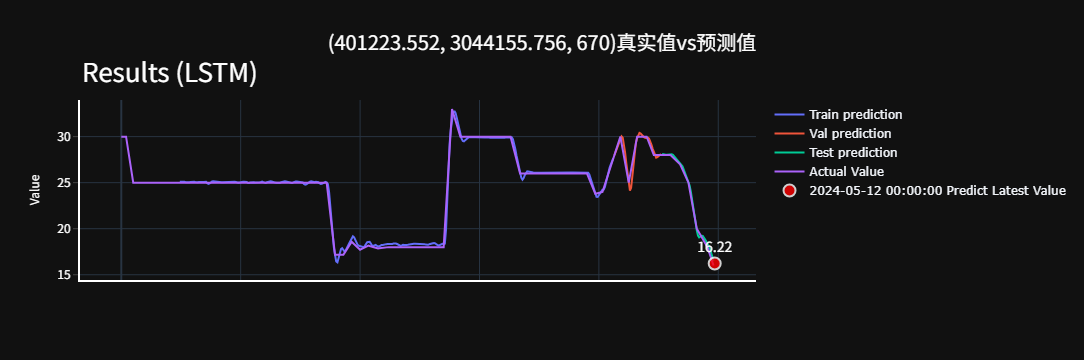

In [7]:
# 按'横坐标', '纵坐标', '高程'进行分组
grouped = df.groupby(['经度', '纬度', '高程'])

# 模型超参数
input_dim = 2
hidden_dim = 60
num_layers = 3
output_dim = 1
num_epochs = 50
lookback = 50

# 该目录用于保存最优模型参数
os.makedirs('lstmmodel', exist_ok=True)

# 该目录用于保存最优模型训练数据标准化格式
os.makedirs('lstmscaler/', exist_ok=True)

# 创建日志目录
os.makedirs('logs', exist_ok=True)

for name, group in grouped:
    # try:
        # 创建唯一的日志文件名
        log_file = f"logs/{name}training.log"
        logger = Logger(log_file)
        logger.log(f"Group: {name}")
    
        # 提取标签
        target = group[['日降雨量', '涌水量']].copy()

        # 尝试转换日期列，设置errors参数处理无效格式
        group['日期'] = pd.to_datetime(group['日期'], errors='coerce')
        # 获取最新的一天
        latest_date = group['日期'].iloc[-1]  # 读取最后一行的日期
        # 计算后一天
        next_day = latest_date + timedelta(days=1)

        # 归一化
        scaler = MinMaxScaler(feature_range=(-1, 1))
        target['日降雨量'] = scaler.fit_transform(target['日降雨量'].values.reshape(-1, 1))
        target['涌水量'] = scaler.fit_transform(target['涌水量'].values.reshape(-1, 1))

        best_scaler_path = 'lstmscaler/' + f'{name}' + 'best_scaler.pkl'
        logger.log('模型标准化格式保存路径：' + best_scaler_path)

        # 保存标准化参数
        joblib.dump(scaler, best_scaler_path)

        x_train, y_train, x_val, y_val, x_test, y_test, x_latest = split_data(target, lookback)
        print('x_train.shape = ', x_train.shape)
        print('y_train.shape = ', y_train.shape)
        print('x_val.shape = ', x_val.shape)
        print('y_val.shape = ', y_val.shape)
        print('x_test.shape = ', x_test.shape)
        print('y_test.shape = ', y_test.shape)
        print('x_latest.shape = ', x_latest.shape)

        # 转换成张量,神经网络模型的数据要求为张量类型
        x_train = torch.from_numpy(x_train).type(torch.Tensor)
        x_test = torch.from_numpy(x_test).type(torch.Tensor)
        x_val = torch.from_numpy(x_val).type(torch.Tensor)
        y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)
        y_val_lstm = torch.from_numpy(y_val).type(torch.Tensor)
        y_test_lstm = torch.from_numpy(y_test).type(torch.Tensor)
        x_latest_tensor = torch.from_numpy(x_latest).type(torch.Tensor)

        # 模型实例化准备开始训练
        model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
        criterion = torch.nn.MSELoss()
        optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

        hist = np.zeros(num_epochs)
        start_time = time.time()
        best_val_loss = float('inf')  # 用于保存验证集上的最佳损失
        best_model_path = 'lstmmodel/' + f'{name}' + 'best_model.pth'  # 最佳模型保存路径
        val_hist = np.zeros(num_epochs)  # 记录验证损失
        logger.log('最优模型参数保存路径：' + best_model_path)

        for t in range(num_epochs):
            # 训练模式
            model.train()

            y_train_pred = model(x_train)

            loss = criterion(y_train_pred, y_train_lstm)
            logger.log("Epoch " + str(t) + " MSE: " + str(loss.item()))
            hist[t] = loss.item()

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            # 验证模式
            model.eval()
            with torch.no_grad():  # 禁用梯度计算
                y_val_pred = model(x_val)
                # 反归一化
                y_val_pred_1 = scaler.inverse_transform(y_val_pred.detach().numpy())
                y_val_1 = scaler.inverse_transform(y_val_lstm.detach().numpy())
                val_loss = math.sqrt(mean_squared_error(y_val_1[:, 0], y_val_pred_1[:, 0]))
                # print("Epoch ", t, "val RMSE: ", val_loss)
                logger.log("Epoch " + str(t) + " val RMSE: " + str(val_loss))
                val_hist[t] = val_loss

                # 如果验证损失更好，则保存模型
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(model.state_dict(), best_model_path)
                    # print(f"Best model saved at epoch {t} with Test RMSE: {best_val_loss}")
                    logger.log(f"Best model saved at epoch {t} with Test RMSE: {best_val_loss}")

        training_time = time.time() - start_time
        # print("Training time: {}".format(training_time))
        logger.log("Training time: {}".format(training_time))
        logger.log(f"{name} 训练完成\n")

        # 模型结果可视化
        predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
        original = pd.DataFrame(scaler.inverse_transform(y_train_lstm.detach().numpy()))
        sns.set_style("darkgrid")
        fig = plt.figure()
        fig.subplots_adjust(hspace=0.2, wspace=0.2)
        plt.subplot(1, 2, 1)
        ax = sns.lineplot(x=original.index, y=original[0], label="origin", color='royalblue')
        ax = sns.lineplot(x=predict.index, y=predict[0], label="predict", color='tomato')
        ax.set_title(f'{name}训练集LSTM预测结果对比', size=14, fontweight='bold', fontfamily=["SimHei"])
        ax.set_xlabel("Time", size=14)
        ax.set_ylabel("Data", size=14)
        ax.set_xticklabels('', size=10)

        plt.subplot(1, 2, 2)
        ax = sns.lineplot(data=hist, color='royalblue')
        ax.set_xlabel("Epoch", size=14)
        ax.set_ylabel("Loss", size=14)
        ax.set_title(f'{name} Trainset Loss', size=14, fontweight='bold')
        fig.set_figheight(6)
        fig.set_figwidth(16)
        # 保存训练集可视化结果到指定目录
        image_path = f'./images/{name}LSTM训练集可视化结果.png'
        plt.savefig(image_path, dpi=300, bbox_inches="tight")
        logger.log(f'./images/{name}LSTM训练集可视化结果.png保存成功')
        plt.show()

        # 加载最优模型参数
        model.load_state_dict(torch.load(best_model_path, weights_only=True))
        model.eval()  # 将模型设置为评估模式

        # 加载归一化格式
        scaler = joblib.load(best_scaler_path)

        # 构造最新一天预测的输入,即最新的lookback天作为模型输入
        

        # 在测试集上验证
        with torch.no_grad():  # 禁用梯度计算
            y_test_pred = model(x_test)
            y_train_pred = model(x_train)
            y_val_pred = model(x_val)
            y_latest_pred = model(x_latest_tensor)

        # 归一化数据回到原来状态
        y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
        y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())
        y_val_pred = scaler.inverse_transform(y_val_pred.detach().numpy())
        y_val = scaler.inverse_transform(y_val_lstm.detach().numpy())
        y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
        y_test = scaler.inverse_transform(y_test_lstm.detach().numpy())
        y_latest_pred = scaler.inverse_transform(y_latest_pred.detach().numpy())

        # 计算训练集、验证集和测试集的均方误差
        trainScore = math.sqrt(mean_squared_error(y_train[:, 0], y_train_pred[:, 0]))
        logger.log('Train Score: %.2f RMSE' % (trainScore))
        valScore = math.sqrt(mean_squared_error(y_val[:, 0], y_val_pred[:, 0]))
        logger.log('Train Score: %.2f RMSE' % (valScore))
        testScore = math.sqrt(mean_squared_error(y_test[:, 0], y_test_pred[:, 0]))
        logger.log('Test Score: %.2f RMSE' % (testScore))

        # 制作可视化数据集
        new_target = target[['涌水量']]

        # 转换数据
        trainPredictPlot = np.empty((len(new_target) + 1, new_target.shape[1]))
        trainPredictPlot[:] = np.nan  # 初始化为NaN
        trainPredictPlot[lookback - 1:len(y_train_pred) + lookback - 1, :] = y_train_pred

        valPredictPlot = np.empty((len(new_target) + 1, new_target.shape[1]))
        valPredictPlot[:] = np.nan  # 初始化为NaN
        valPredictPlot[len(y_train_pred) + lookback - 1:len(y_train_pred) + lookback - 1 + len(y_val_pred),
        :] = y_val_pred

        testPredictPlot = np.empty((len(new_target) + 1, new_target.shape[1]))
        testPredictPlot[:] = np.nan  # 初始化为NaN
        testPredictPlot[len(y_train_pred) + lookback - 1 + len(y_val_pred):-1, :] = y_test_pred

        original = scaler.inverse_transform(target['涌水量'].values.reshape(-1,1))
        originPlot = np.empty((len(new_target) + 1, new_target.shape[1]))
        originPlot[:] = np.nan  # 初始化为NaN
        originPlot[0:original.shape[0], :] = original

        latestPredictPlot = np.empty((len(new_target) + 1, new_target.shape[1]))
        latestPredictPlot[:] = np.nan  # 初始化为NaN
        latestPredictPlot[-1:, :] = y_latest_pred

        predictions = np.append(trainPredictPlot, valPredictPlot, axis=1)
        predictions = np.append(predictions, testPredictPlot, axis=1)
        predictions = np.append(predictions, originPlot, axis=1)
        predictions = np.append(predictions, latestPredictPlot, axis=1)
        result = pd.DataFrame(predictions)

        # 将集合好的result画图可视化
        fig = go.Figure()
        fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0],
                                            mode='lines',
                                            name='Train prediction')))
        fig.add_trace(go.Scatter(x=result.index, y=result[1],
                                 mode='lines',
                                 name='Val prediction'))
        fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2],
                                            mode='lines',
                                            name='Test prediction')))
        fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[3],
                                            mode='lines',
                                            name='Actual Value')))
        
        # 新增预测最新值的散点图（明显标注的点+数值标签）
        fig.add_trace(go.Scatter(
            x=result.index, 
            y=result[4],  # 第5列：预测最新值
            mode='markers+text',  # 同时显示标记点和文本
            name=f'{next_day} Predict Latest Value',
            marker=dict(
                size=12,           # 点的大小
                color='red',       # 点的颜色
                symbol='circle',   # 点的形状
                line=dict(         # 点的边框
                    width=2,
                    color='white'
                ),
                opacity=0.8        # 点的透明度
            ),
            text=[f"{y:.2f}" for y in result[4]],  # 标签文本（保留两位小数）
            textposition='top center',  # 文本位置（点的上方居中）
            textfont=dict(
                family="Rockwell",
                size=14,
                color="white"
            )
        ))

        fig.update_layout(
            title={
                'text': f'{name}真实值vs预测值',  # 替换为您的标题文本
                'x': 0.5,  # 标题水平居中
                'xanchor': 'center',
                'y': 0.9,  # 标题在图表的顶部
                'yanchor': 'top',
                'font': {
                    'family': "Rockwell",
                    'size': 20,
                    'color': 'white'
                }
            },
            xaxis=dict(
                showline=True,
                showgrid=True,
                showticklabels=False,
                linecolor='white',
                linewidth=2
            ),
            yaxis=dict(
                title_text="Value",
                title_font=dict(
                    family='Rockwell',
                    size=12,
                    color='white',
                ),
                showline=True,
                showgrid=True,
                showticklabels=True,
                linecolor='white',
                linewidth=2,
                ticks='outside',
                tickfont=dict(
                    family='Rockwell',
                    size=12,
                    color='white',
                ),
            ),
            showlegend=True,
            template='plotly_dark'

        )

        annotations = []
        annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                                xanchor='left', yanchor='bottom',
                                text='Results (LSTM)',
                                font=dict(family='Rockwell',
                                          size=26,
                                          color='white'),
                                showarrow=False))
        fig.update_layout(annotations=annotations)
        # 保存可视化结果
        image_path = f'./images/{name}真实值vs预测值.png'
        fig.write_image(image_path, width=1200, height=600, scale=2,engine='orca')
        logger.log(f'./images/{name}真实值vs预测值.png保存成功')
        fig.show()
    # except Exception as e:
    #     logger.log(f"训练过程中发生错误: {str(e)}")